# eCommerce Behavior Data — EDA

Multi-category store event log (Oct + Nov 2019, ~110M rows).

**Approach**: heavy aggregation runs in **DuckDB** (streams the 14GB CSVs, no full load into RAM); results come back as small pandas DataFrames for **matplotlib** charts.

Columns: `event_time, event_type(view/cart/purchase), product_id, category_id, category_code, brand, price, user_id, user_session`

## Setup

In [4]:
import glob
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Resolve the data dir relative to the repo root, regardless of where the
# kernel's cwd is (project root or eda/). Falls back to ./data.
ROOT = Path.cwd()
if (ROOT / "eda").is_dir() and not (ROOT / "data").is_dir():
    pass  # cwd is already root
for cand in (ROOT, ROOT.parent):
    if (cand / "data").is_dir():
        ROOT = cand
        break
DATA_GLOB = str(ROOT / "data" / "2019-*.csv")

files = glob.glob(DATA_GLOB)
if not files:
    raise FileNotFoundError(
        f"No CSVs match {DATA_GLOB!r}. "
        "Launch Jupyter from the project root and ensure data/2019-*.csv exist."
    )
print("Found:", [Path(f).name for f in files])

con = duckdb.connect()  # in-memory
con.sql(f"""
    CREATE OR REPLACE VIEW events AS
    SELECT * FROM read_csv_auto('{DATA_GLOB.replace(chr(92), "/")}', union_by_name=true)
""")

def q(sql: str) -> pd.DataFrame:
    """Run SQL in DuckDB, return a pandas DataFrame."""
    return con.sql(sql).df()

print("DuckDB ready.")

Found: ['2019-Nov.csv', '2019-Oct.csv']
DuckDB ready.


## 1. Dataset overview

In [7]:
q("""
    SELECT
        count(*)                     AS total_rows,
        min(event_time)              AS start_time,
        max(event_time)              AS end_time,
        count(DISTINCT user_id)      AS unique_users,
        count(DISTINCT product_id)   AS unique_products,
        count(DISTINCT user_session) AS unique_sessions
    FROM events
""").T

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,0
total_rows,109950743
start_time,2019-10-01 00:00:00
end_time,2019-11-30 23:59:59
unique_users,5316649
unique_products,206876
unique_sessions,23016650


## 2. Event type distribution

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,event_type,n,pct
0,view,104335509,94.89
1,cart,3955446,3.60
2,purchase,1659788,1.51


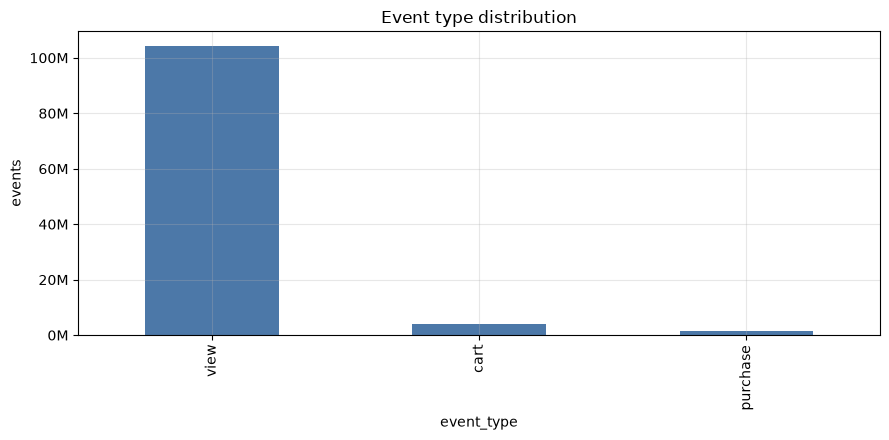

In [3]:
df = q("""
    SELECT event_type, count(*) AS n
    FROM events GROUP BY event_type ORDER BY n DESC
""")
df["pct"] = (100 * df["n"] / df["n"].sum()).round(2)
display(df)

ax = df.plot.bar(x="event_type", y="n", legend=False, color="#4C78A8")
ax.set_title("Event type distribution")
ax.set_ylabel("events")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
plt.tight_layout(); plt.show()

## 3. Conversion funnel (view → cart → purchase)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

view → cart     :  3.79%
cart → purchase : 41.96%
view → purchase :  1.59%


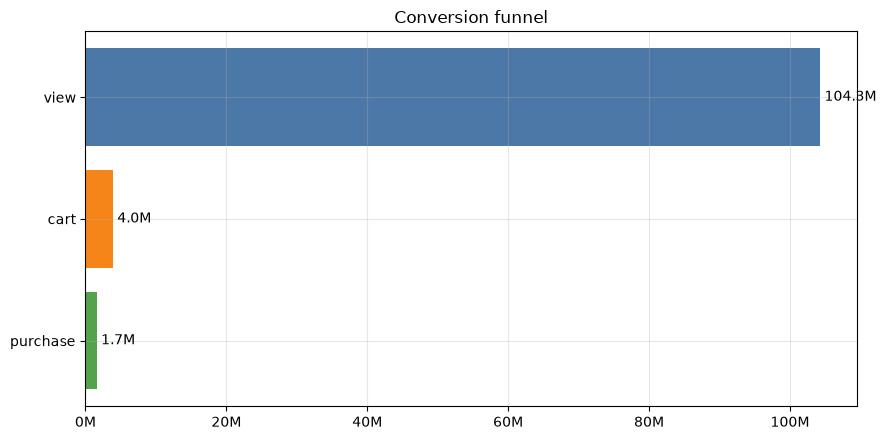

In [8]:
funnel = q("""
    SELECT
        count(*) FILTER (WHERE event_type='view')     AS views,
        count(*) FILTER (WHERE event_type='cart')     AS carts,
        count(*) FILTER (WHERE event_type='purchase') AS purchases
    FROM events
""").iloc[0]

print(f"view → cart     : {100*funnel.carts/funnel.views:5.2f}%")
print(f"cart → purchase : {100*funnel.purchases/funnel.carts:5.2f}%")
print(f"view → purchase : {100*funnel.purchases/funnel.views:5.2f}%")

stages = ["view", "cart", "purchase"]
vals = [funnel.views, funnel.carts, funnel.purchases]
ax = plt.subplot()
bars = ax.barh(stages[::-1], vals[::-1], color=["#54A24B", "#F58518", "#4C78A8"])
ax.set_title("Conversion funnel")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
for b, v in zip(bars, vals[::-1]):
    ax.text(v, b.get_y()+b.get_height()/2, f" {v/1e6:.1f}M", va="center")
plt.tight_layout(); plt.show()

## 4. Revenue by category (purchases)

In [ ]:
cat = q("""
    SELECT category_code,
           count(*)           AS purchases,
           round(sum(price))  AS revenue
    FROM events
    WHERE event_type='purchase' AND category_code IS NOT NULL
    GROUP BY category_code ORDER BY revenue DESC LIMIT 15
""")
display(cat)

ax = cat[::-1].plot.barh(x="category_code", y="revenue", legend=False, color="#4C78A8")
ax.set_title("Top 15 categories by revenue")
ax.set_xlabel("revenue")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
plt.tight_layout(); plt.show()

## 5. Revenue by brand (purchases)

In [ ]:
brand = q("""
    SELECT brand,
           count(*)          AS purchases,
           round(sum(price)) AS revenue
    FROM events
    WHERE event_type='purchase' AND brand IS NOT NULL
    GROUP BY brand ORDER BY revenue DESC LIMIT 15
""")
display(brand)

ax = brand[::-1].plot.barh(x="brand", y="revenue", legend=False, color="#72B7B2")
ax.set_title("Top 15 brands by revenue")
ax.set_xlabel("revenue")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
plt.tight_layout(); plt.show()

## 6. Daily revenue trend

In [ ]:
daily = q("""
    SELECT date_trunc('day', event_time)::DATE AS day,
           round(sum(price)) AS revenue
    FROM events WHERE event_type='purchase'
    GROUP BY day ORDER BY day
""")

ax = daily.plot(x="day", y="revenue", legend=False, color="#4C78A8")
ax.set_title("Daily revenue (Oct–Nov 2019)")
ax.set_ylabel("revenue")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
# annotate the peak day
peak = daily.loc[daily["revenue"].idxmax()]
ax.annotate(f"{peak.day}", xy=(peak.day, peak.revenue),
            xytext=(0, 10), textcoords="offset points", ha="center")
plt.tight_layout(); plt.show()

## 7. Purchases by hour of day (UTC)

In [ ]:
hourly = q("""
    SELECT extract(hour FROM event_time) AS hour, count(*) AS purchases
    FROM events WHERE event_type='purchase'
    GROUP BY hour ORDER BY hour
""")

ax = hourly.plot.bar(x="hour", y="purchases", legend=False, color="#F58518")
ax.set_title("Purchases by hour of day (UTC)")
ax.set_ylabel("purchases")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
plt.tight_layout(); plt.show()

## 8. Day-of-week × hour purchase heatmap

In [ ]:
hm = q("""
    SELECT extract(dow  FROM event_time) AS dow,
           extract(hour FROM event_time) AS hour,
           count(*) AS purchases
    FROM events WHERE event_type='purchase'
    GROUP BY dow, hour
""")
pivot = hm.pivot(index="dow", columns="hour", values="purchases").fillna(0)
days = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

fig, ax = plt.subplots(figsize=(11, 3.5))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(24)); ax.set_xticklabels(range(24))
ax.set_yticks(range(7));  ax.set_yticklabels(days)
ax.set_xlabel("hour (UTC)"); ax.set_title("Purchases: day-of-week × hour")
fig.colorbar(im, ax=ax, label="purchases")
plt.tight_layout(); plt.show()

## 9. Purchase price distribution

In [ ]:
# Bin in DuckDB (cap at $2000 for readability), plot in matplotlib
hist = q("""
    SELECT floor(least(price, 2000)/50)*50 AS price_bin, count(*) AS n
    FROM events WHERE event_type='purchase'
    GROUP BY price_bin ORDER BY price_bin
""")

stats = q("""
    SELECT round(avg(price),2) AS mean,
           round(median(price),2) AS median,
           round(quantile(price,0.9),2) AS p90
    FROM events WHERE event_type='purchase'
""").iloc[0]
print(dict(stats))

ax = ax = plt.subplot()
ax.bar(hist["price_bin"], hist["n"], width=45, color="#4C78A8")
ax.axvline(stats["median"], color="#E45756", ls="--", label=f"median ${stats['median']:.0f}")
ax.set_title("Purchase price distribution (capped at $2000)")
ax.set_xlabel("price ($)"); ax.set_ylabel("purchases"); ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
plt.tight_layout(); plt.show()

## 10. Top repeat buyers

In [ ]:
q("""
    SELECT user_id, count(*) AS purchases, round(sum(price)) AS spent
    FROM events WHERE event_type='purchase'
    GROUP BY user_id ORDER BY purchases DESC LIMIT 10
""")